# Data Exploration - German Household Solar Energy Dataset

This notebook explores the household energy dataset to understand:
- Dataset structure and completeness
- Households with solar PV systems
- Solar generation patterns
- Grid export patterns
- Energy consumption patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
# Load data
data_path = Path('../data/raw/archive (1)/household_data_60min_singleindex.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df['utc_timestamp'].min()} to {df['utc_timestamp'].max()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (38454, 71)

Date range: 2014-12-11T17:00:00Z to 2019-05-01T22:00:00Z

Memory usage: 29.32 MB


In [3]:
# Display first few rows
df.head()

,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,DE_KN_industrial3_area_room_2,DE_KN_industrial3_area_room_3,DE_KN_industrial3_area_room_4,DE_KN_industrial3_compressor,DE_KN_industrial3_cooling_aggregate,DE_KN_industrial3_cooling_pumps,DE_KN_industrial3_dishwasher,DE_KN_industrial3_ev,DE_KN_industrial3_grid_import,DE_KN_industrial3_machine_1,DE_KN_industrial3_machine_2,DE_KN_industrial3_machine_3,DE_KN_industrial3_machine_4,DE_KN_industrial3_machine_5,DE_KN_industrial3_pv_facade,DE_KN_industrial3_pv_roof,DE_KN_industrial3_refrigerator,DE_KN_industrial3_ventilation,DE_KN_public1_grid_import,DE_KN_public2_grid_import,DE_KN_residential1_dishwasher,DE_KN_residential1_freezer,DE_KN_residential1_grid_import,DE_KN_residential1_heat_pump,DE_KN_residential1_pv,DE_KN_residential1_washing_machine,DE_KN_residential2_circulation_pump,DE_KN_residential2_dishwasher,DE_KN_residential2_freezer,DE_KN_residential2_grid_import,DE_KN_residential2_washing_machine,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine,DE_KN_residential4_dishwasher,DE_KN_residential4_ev,DE_KN_residential4_freezer,DE_KN_residential4_grid_export,DE_KN_residential4_grid_import,DE_KN_residential4_heat_pump,DE_KN_residential4_pv,DE_KN_residential4_refrigerator,DE_KN_residential4_washing_machine,DE_KN_residential5_dishwasher,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:00:00Z,2014-12-11T18:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.063,0.003,0.024,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T19:00:00Z,2014-12-11T20:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.132,0.005,0.064,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T20:00:00Z,2014-12-11T21:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.200,0.008,0.102,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T21:00:00Z,2014-12-11T22:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.269,0.010,0.106,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Dataset Structure Analysis

In [4]:
# Column names and data types
print("Column Information:")
print(df.info())

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38454 entries, 0 to 38453
Data columns (total 71 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   utc_timestamp                        38454 non-null  object 
 1   cet_cest_timestamp                   38454 non-null  object 
 2   DE_KN_industrial1_grid_import        16434 non-null  float64
 3   DE_KN_industrial1_pv_1               17288 non-null  float64
 4   DE_KN_industrial1_pv_2               17288 non-null  float64
 5   DE_KN_industrial2_grid_import        11279 non-null  float64
 6   DE_KN_industrial2_pv                 12000 non-null  float64
 7   DE_KN_industrial2_storage_charge     9754 non-null   float64
 8   DE_KN_industrial2_storage_decharge   9754 non-null   float64
 9   DE_KN_industrial3_area_offices       14360 non-null  float64
 10  DE_KN_industrial3_area_room_1        14360 non-null  float64
 11  DE_KN_in

In [5]:
# Identify columns by category
residential_cols = [col for col in df.columns if 'residential' in col]
pv_cols = [col for col in residential_cols if 'pv' in col]
grid_export_cols = [col for col in residential_cols if 'grid_export' in col]
grid_import_cols = [col for col in residential_cols if 'grid_import' in col]

print("\n=== SOLAR PV COLUMNS ===")
for col in pv_cols:
    print(f"  {col}")

print("\n=== GRID EXPORT COLUMNS ===")
for col in grid_export_cols:
    print(f"  {col}")

print("\n=== GRID IMPORT COLUMNS ===")
for col in grid_import_cols:
    print(f"  {col}")


=== SOLAR PV COLUMNS ===
  DE_KN_residential1_pv
  DE_KN_residential3_pv
  DE_KN_residential4_pv
  DE_KN_residential6_pv

=== GRID EXPORT COLUMNS ===
  DE_KN_residential3_grid_export
  DE_KN_residential4_grid_export
  DE_KN_residential6_grid_export

=== GRID IMPORT COLUMNS ===
  DE_KN_residential1_grid_import
  DE_KN_residential2_grid_import
  DE_KN_residential3_grid_import
  DE_KN_residential4_grid_import
  DE_KN_residential5_grid_import
  DE_KN_residential6_grid_import


## 3. Identify Households with Solar PV and Grid Export

In [6]:
# Check which households have PV data
households = ['residential1', 'residential2', 'residential3', 'residential4', 'residential5', 'residential6']

print("\n=== HOUSEHOLD SOLAR CAPABILITIES ===")
for household in households:
    pv_col = f'DE_KN_{household}_pv'
    export_col = f'DE_KN_{household}_grid_export'
    import_col = f'DE_KN_{household}_grid_import'
    
    has_pv = pv_col in df.columns and df[pv_col].notna().sum() > 0
    has_export = export_col in df.columns and df[export_col].notna().sum() > 0
    has_import = import_col in df.columns and df[import_col].notna().sum() > 0
    
    if has_pv:
        print(f"\n{household.upper()}:")
        print(f"  ✓ Has PV: {df[pv_col].notna().sum()} records")
        print(f"  ✓ Has Grid Export: {has_export} ({df[export_col].notna().sum() if has_export else 0} records)")
        print(f"  ✓ Has Grid Import: {has_import} ({df[import_col].notna().sum() if has_import else 0} records)")
        
        if has_pv:
            print(f"  Total PV Generation: {df[pv_col].sum():.2f} kWh")
        if has_export:
            print(f"  Total Grid Export: {df[export_col].sum():.2f} kWh")


=== HOUSEHOLD SOLAR CAPABILITIES ===

RESIDENTIAL1:
  ✓ Has PV: 15873 records
  ✓ Has Grid Export: False (0 records)
  ✓ Has Grid Import: True (15873 records)
  Total PV Generation: 148147935.99 kWh

RESIDENTIAL3:
  ✓ Has PV: 22555 records
  ✓ Has Grid Export: True (22555 records)
  ✓ Has Grid Import: True (11904 records)
  Total PV Generation: 149274703.89 kWh
  Total Grid Export: 98777326.84 kWh

RESIDENTIAL4:
  ✓ Has PV: 20360 records
  ✓ Has Grid Export: True (20360 records)
  ✓ Has Grid Import: True (20360 records)
  Total PV Generation: 239125500.54 kWh
  Total Grid Export: 186131351.88 kWh

RESIDENTIAL6:
  ✓ Has PV: 21534 records
  ✓ Has Grid Export: True (16690 records)
  ✓ Has Grid Import: True (21534 records)
  Total PV Generation: 216270217.33 kWh
  Total Grid Export: 36368430.66 kWh


## 4. Missing Data Analysis

In [7]:
# Missing data for key columns
key_cols = pv_cols + grid_export_cols + grid_import_cols
missing_data = pd.DataFrame({
    'Column': key_cols,
    'Missing': [df[col].isna().sum() for col in key_cols],
    'Missing %': [df[col].isna().sum() / len(df) * 100 for col in key_cols],
    'Non-Zero Values': [df[col].gt(0).sum() for col in key_cols]
})

print("\n=== MISSING DATA SUMMARY ===")
print(missing_data.sort_values('Missing %', ascending=False))


=== MISSING DATA SUMMARY ===
                            Column  Missing  Missing %  Non-Zero Values
9   DE_KN_residential3_grid_import    26550  69.043533            11904
8   DE_KN_residential2_grid_import    22656  58.917148            15798
7   DE_KN_residential1_grid_import    22581  58.722110            15873
0            DE_KN_residential1_pv    22581  58.722110            15873
6   DE_KN_residential6_grid_export    21764  56.597493            16690
5   DE_KN_residential4_grid_export    18094  47.053623            20346
10  DE_KN_residential4_grid_import    18094  47.053623            20360
2            DE_KN_residential4_pv    18094  47.053623            20346
3            DE_KN_residential6_pv    16920  44.000624            21521
12  DE_KN_residential6_grid_import    16920  44.000624            21534
1            DE_KN_residential3_pv    15899  41.345504            22542
4   DE_KN_residential3_grid_export    15899  41.345504            22539
11  DE_KN_residential5_grid_import

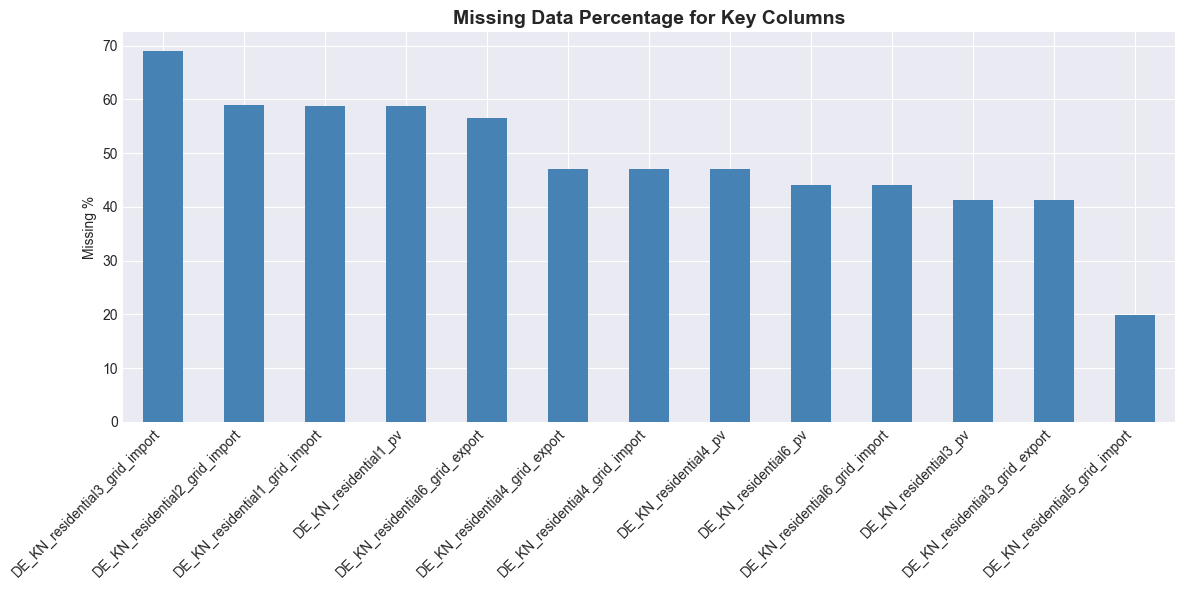

In [8]:
# Visualize missing data
plt.figure(figsize=(12, 6))
missing_pct = (df[key_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct.plot(kind='bar', color='steelblue')
plt.title('Missing Data Percentage for Key Columns', fontsize=14, fontweight='bold')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Time Series Analysis

In [9]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['utc_timestamp'])
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total days: {df['date'].nunique()}")
print(f"Total hours: {len(df)}")

Date range: 2014-12-11 to 2019-05-01
Total days: 1603
Total hours: 38454


## 6. Solar PV Generation Analysis

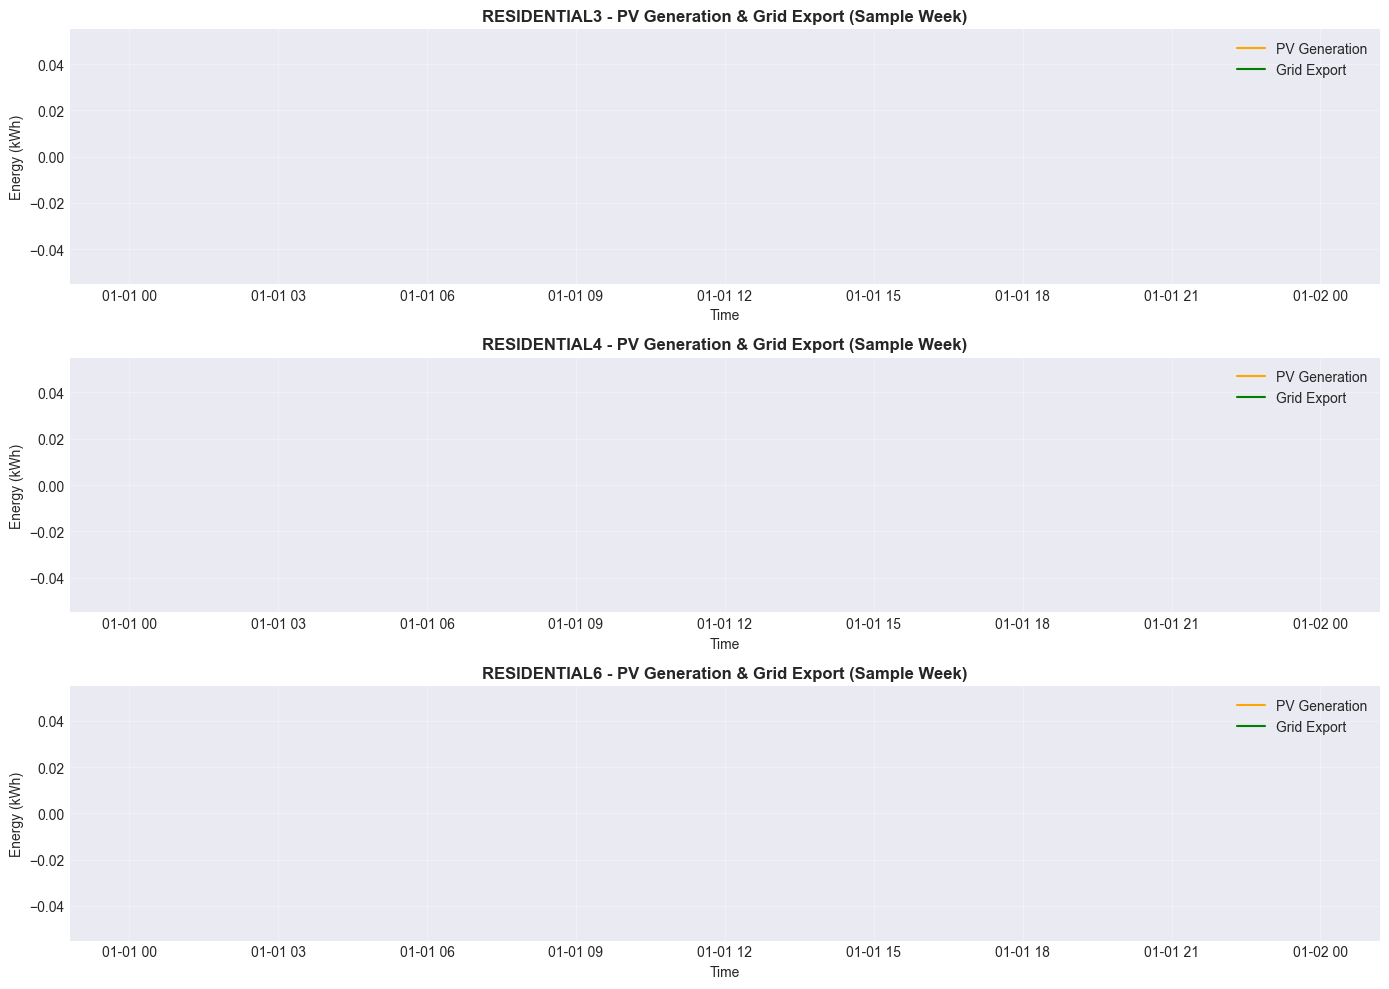

In [10]:
# Focus on households with both PV and grid export
solar_households = ['residential3', 'residential4', 'residential6']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, household in enumerate(solar_households):
    pv_col = f'DE_KN_{household}_pv'
    export_col = f'DE_KN_{household}_grid_export'
    
    if pv_col in df.columns:
        # Sample a week of data for visualization
        sample_data = df[df['timestamp'].between('2015-06-01', '2015-06-08')].copy()
        
        ax = axes[idx]
        ax.plot(sample_data['timestamp'], sample_data[pv_col], label='PV Generation', linewidth=1.5, color='orange')
        
        if export_col in df.columns:
            ax.plot(sample_data['timestamp'], sample_data[export_col], label='Grid Export', linewidth=1.5, color='green')
        
        ax.set_title(f'{household.upper()} - PV Generation & Grid Export (Sample Week)', fontweight='bold')
        ax.set_xlabel('Time')
        ax.set_ylabel('Energy (kWh)')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Daily Aggregation Preview

In [11]:
# Create daily aggregates for one household as example
household = 'residential3'
pv_col = f'DE_KN_{household}_pv'
export_col = f'DE_KN_{household}_grid_export'
import_col = f'DE_KN_{household}_grid_import'

# Daily totals
daily_data = df.groupby('date').agg({
    pv_col: 'sum',
    export_col: 'sum',
    import_col: 'sum'
}).reset_index()

daily_data.columns = ['date', 'daily_pv', 'daily_export', 'daily_import']

print(f"\n=== DAILY DATA PREVIEW ({household.upper()}) ===")
print(daily_data.head(10))
print(f"\nDaily Statistics:")
print(daily_data[['daily_pv', 'daily_export', 'daily_import']].describe())


=== DAILY DATA PREVIEW (RESIDENTIAL3) ===
         date  daily_pv  daily_export  daily_import
0  2014-12-11       0.0           0.0           0.0
1  2014-12-12       0.0           0.0           0.0
2  2014-12-13       0.0           0.0           0.0
3  2014-12-14       0.0           0.0           0.0
4  2014-12-15       0.0           0.0           0.0
5  2014-12-16       0.0           0.0           0.0
6  2014-12-17       0.0           0.0           0.0
7  2014-12-18       0.0           0.0           0.0
8  2014-12-19       0.0           0.0           0.0
9  2014-12-20       0.0           0.0           0.0

Daily Statistics:
            daily_pv   daily_export   daily_import
count    1603.000000    1603.000000    1603.000000
mean    93122.086021   61620.291227   18632.870215
std    103780.650586   69153.838454   34408.349306
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%     57265.584000   37501.702000       0.000000
75%    19

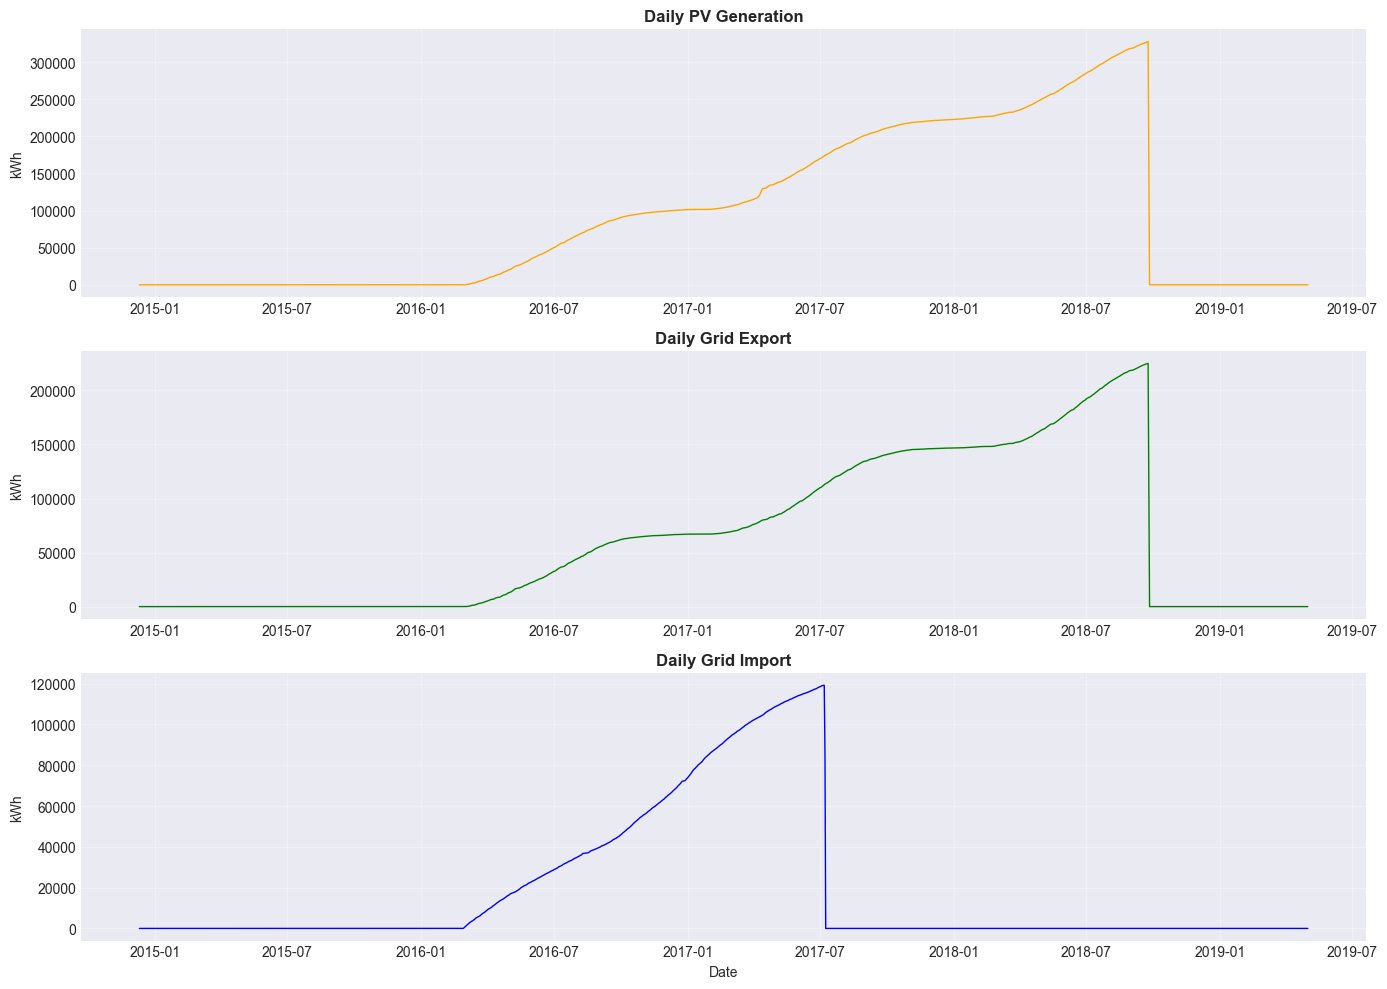

In [12]:
# Visualize daily patterns
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Daily PV
axes[0].plot(daily_data['date'], daily_data['daily_pv'], linewidth=1, color='orange')
axes[0].set_title('Daily PV Generation', fontweight='bold')
axes[0].set_ylabel('kWh')
axes[0].grid(True, alpha=0.3)

# Daily Export
axes[1].plot(daily_data['date'], daily_data['daily_export'], linewidth=1, color='green')
axes[1].set_title('Daily Grid Export', fontweight='bold')
axes[1].set_ylabel('kWh')
axes[1].grid(True, alpha=0.3)

# Daily Import
axes[2].plot(daily_data['date'], daily_data['daily_import'], linewidth=1, color='blue')
axes[2].set_title('Daily Grid Import', fontweight='bold')
axes[2].set_ylabel('kWh')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Calculate Potential Wastage (Preview)

Here we'll calculate the target variable using an assumed grid export limit.

In [13]:
# Assume grid export limit
EXPORT_LIMIT_KWH = 5  # kWh per day

# Calculate wastage
daily_data['wasted_energy'] = daily_data['daily_export'].apply(
    lambda x: max(0, x - EXPORT_LIMIT_KWH) if pd.notna(x) else 0
)

print(f"\n=== WASTAGE CALCULATION PREVIEW ===")
print(f"Export Limit: {EXPORT_LIMIT_KWH} kWh/day\n")
print(daily_data[['date', 'daily_pv', 'daily_export', 'wasted_energy']].head(20))

print(f"\nWastage Statistics:")
print(daily_data['wasted_energy'].describe())
print(f"\nDays with wastage: {(daily_data['wasted_energy'] > 0).sum()}")
print(f"Total wasted energy: {daily_data['wasted_energy'].sum():.2f} kWh")


=== WASTAGE CALCULATION PREVIEW ===
Export Limit: 5 kWh/day

          date  daily_pv  daily_export  wasted_energy
0   2014-12-11       0.0           0.0            0.0
1   2014-12-12       0.0           0.0            0.0
2   2014-12-13       0.0           0.0            0.0
3   2014-12-14       0.0           0.0            0.0
4   2014-12-15       0.0           0.0            0.0
5   2014-12-16       0.0           0.0            0.0
6   2014-12-17       0.0           0.0            0.0
7   2014-12-18       0.0           0.0            0.0
8   2014-12-19       0.0           0.0            0.0
9   2014-12-20       0.0           0.0            0.0
10  2014-12-21       0.0           0.0            0.0
11  2014-12-22       0.0           0.0            0.0
12  2014-12-23       0.0           0.0            0.0
13  2014-12-24       0.0           0.0            0.0
14  2014-12-25       0.0           0.0            0.0
15  2014-12-26       0.0           0.0            0.0
16  2014-12-27      

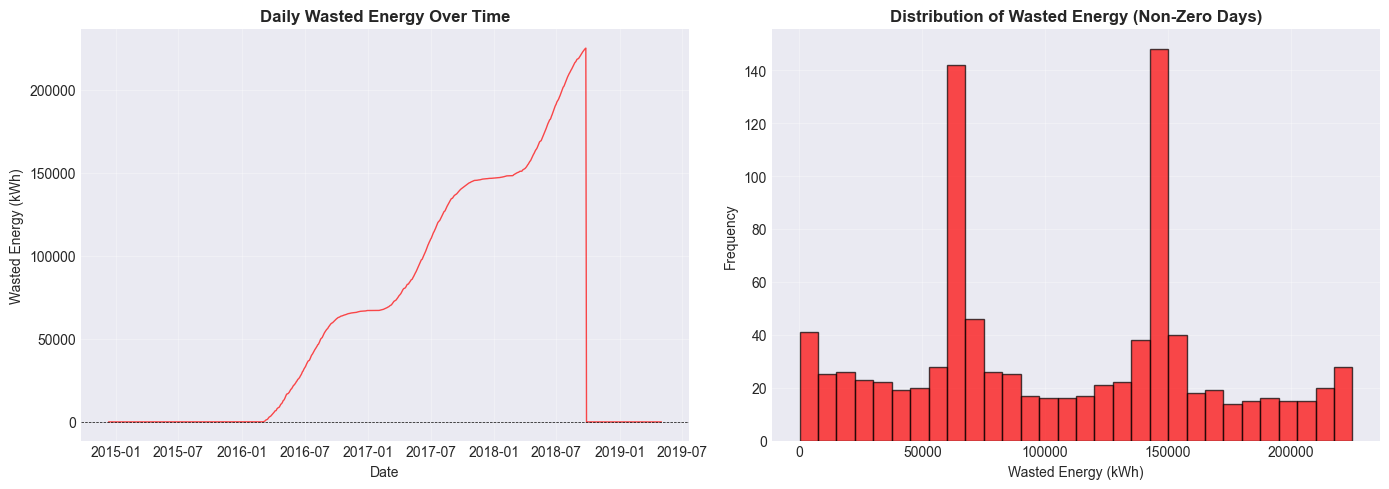

In [14]:
# Visualize wastage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series
axes[0].plot(daily_data['date'], daily_data['wasted_energy'], linewidth=1, color='red', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[0].set_title('Daily Wasted Energy Over Time', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Wasted Energy (kWh)')
axes[0].grid(True, alpha=0.3)

# Distribution
axes[1].hist(daily_data[daily_data['wasted_energy'] > 0]['wasted_energy'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Wasted Energy (Non-Zero Days)', fontweight='bold')
axes[1].set_xlabel('Wasted Energy (kWh)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Auto-Detect and Create Complete Daily Dataset

This section auto-detects columns and creates a comprehensive daily dataset for ALL households with solar PV.

In [3]:
# Step 1: Auto-detect datetime column
print("="*70)
print("STEP 1: AUTO-DETECTING DATETIME COLUMN")
print("="*70)

datetime_candidates = ['datetime', 'timestamp', 'time', 'date_time', 'utc_timestamp', 'cet_cest_timestamp']
datetime_col = None

for col in df.columns:
    if col.lower() in datetime_candidates or any(candidate in col.lower() for candidate in ['timestamp', 'datetime']):
        datetime_col = col
        print(f"✓ Found datetime column: '{datetime_col}'")
        break

if datetime_col is None:
    print("❌ ERROR: Could not find datetime column!")
    print(f"Available columns: {list(df.columns[:10])}...")
else:
    if df[datetime_col].dtype != 'datetime64[ns]':
        df['timestamp'] = pd.to_datetime(df[datetime_col], errors='coerce')
        print(f"✓ Parsed '{datetime_col}' to datetime")
    else:
        df['timestamp'] = df[datetime_col]
    
    # Keep as pandas datetime (normalized to day start) for stable merging/export
    df['date'] = df['timestamp'].dt.normalize()
    print(f"✓ Created normalized datetime date column")
    print(f"  Date range: {df['date'].min()} to {df['date'].max()}")

STEP 1: AUTO-DETECTING DATETIME COLUMN
✓ Found datetime column: 'utc_timestamp'
✓ Parsed 'utc_timestamp' to datetime
✓ Created normalized datetime date column
  Date range: 2014-12-11 00:00:00+00:00 to 2019-05-01 00:00:00+00:00


In [4]:
# Step 2: Auto-detect PV generation columns (all households)
print("\n" + "="*70)
print("STEP 2: AUTO-DETECTING PV GENERATION COLUMNS")
print("="*70)

pv_keywords = ['pv', 'solar', 'generation', 'photovoltaic']
pv_columns = []

for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in pv_keywords):
        # Check if it has actual data
        if df[col].notna().sum() > 0 and df[col].sum() > 0:
            pv_columns.append(col)
            print(f"✓ Found PV column: '{col}' - {df[col].notna().sum()} records, Total: {df[col].sum():.2f} kWh")

if len(pv_columns) == 0:
    print("❌ ERROR: Could not find any PV generation columns!")
else:
    print(f"\n✓ Total PV columns found: {len(pv_columns)}")


STEP 2: AUTO-DETECTING PV GENERATION COLUMNS
✓ Found PV column: 'DE_KN_industrial1_pv_1' - 17288 records, Total: 78150298.94 kWh
✓ Found PV column: 'DE_KN_industrial1_pv_2' - 17288 records, Total: 61291444.37 kWh
✓ Found PV column: 'DE_KN_industrial2_pv' - 12000 records, Total: 128758025.54 kWh
✓ Found PV column: 'DE_KN_industrial3_pv_facade' - 14360 records, Total: 55591128.85 kWh
✓ Found PV column: 'DE_KN_industrial3_pv_roof' - 14360 records, Total: 126700904.81 kWh
✓ Found PV column: 'DE_KN_residential1_pv' - 15873 records, Total: 148147935.99 kWh
✓ Found PV column: 'DE_KN_residential3_pv' - 22555 records, Total: 149274703.89 kWh
✓ Found PV column: 'DE_KN_residential4_pv' - 20360 records, Total: 239125500.54 kWh
✓ Found PV column: 'DE_KN_residential6_pv' - 21534 records, Total: 216270217.33 kWh

✓ Total PV columns found: 9


In [5]:
# Step 3: Auto-detect load/consumption columns for each household
print("\n" + "="*70)
print("STEP 3: AUTO-DETECTING LOAD/CONSUMPTION COLUMNS")
print("="*70)

load_keywords = ['load', 'consumption', 'demand', 'grid_import']
exclude_keywords = ['export', 'pv', 'solar']

# For each household with PV, find their consumption columns
household_data = {}

for pv_col in pv_columns:
    # Extract household identifier (e.g., 'residential3' from 'DE_KN_residential3_pv')
    household_id = None
    for part in pv_col.split('_'):
        if 'residential' in part.lower():
            household_id = part
            break
    
    if household_id:
        # Find all columns for this household (excluding PV and export)
        household_cols = [col for col in df.columns 
                         if household_id in col 
                         and not any(ex in col.lower() for ex in ['pv', 'export'])]
        
        # These are the load columns (appliances + grid import)
        load_cols = [col for col in household_cols if df[col].notna().sum() > 0]
        
        household_data[household_id] = {
            'pv_col': pv_col,
            'load_cols': load_cols,
            'grid_import': f'DE_KN_{household_id}_grid_import' if f'DE_KN_{household_id}_grid_import' in df.columns else None
        }
        
        print(f"\n✓ {household_id.upper()}:")
        print(f"    PV: {pv_col}")
        print(f"    Load columns: {len(load_cols)} columns")
        if household_data[household_id]['grid_import']:
            print(f"    Grid Import: {household_data[household_id]['grid_import']}")

print(f"\n✓ Total households with PV: {len(household_data)}")


STEP 3: AUTO-DETECTING LOAD/CONSUMPTION COLUMNS

✓ RESIDENTIAL1:
    PV: DE_KN_residential1_pv
    Load columns: 5 columns
    Grid Import: DE_KN_residential1_grid_import

✓ RESIDENTIAL3:
    PV: DE_KN_residential3_pv
    Load columns: 6 columns
    Grid Import: DE_KN_residential3_grid_import

✓ RESIDENTIAL4:
    PV: DE_KN_residential4_pv
    Load columns: 7 columns
    Grid Import: DE_KN_residential4_grid_import

✓ RESIDENTIAL6:
    PV: DE_KN_residential6_pv
    Load columns: 5 columns
    Grid Import: DE_KN_residential6_grid_import

✓ Total households with PV: 4


In [6]:
# Step 4: Aggregate to daily totals for ALL households with robust unit handling
print("\n" + "="*70)
print("STEP 4: AGGREGATING TO DAILY TOTALS")
print("="*70)

MAX_INTERVAL_KWH = 50   # if interval value is above this, likely Wh-scaled
MAX_DAILY_KWH = 200     # if daily sum is above this, likely Wh-scaled
SMALL_GAP_LIMIT_DAYS = 2

all_daily_records = []

def to_kwh_if_needed(series, date_index, label):
    s = pd.to_numeric(series, errors='coerce')
    if s.notna().sum() == 0:
        print(f"    - {label}: no valid values")
        return s
    
    interval_max = s.max(skipna=True)
    daily_sum_max = s.groupby(date_index).sum(min_count=1).max(skipna=True)
    needs_scale = (pd.notna(interval_max) and interval_max > MAX_INTERVAL_KWH) or (pd.notna(daily_sum_max) and daily_sum_max > MAX_DAILY_KWH)
    
    if needs_scale:
        print(f"    - {label}: scaled from Wh-like values to kWh (interval max={interval_max:.2f}, daily max={daily_sum_max:.2f})")
        s = s / 1000.0
    else:
        print(f"    - {label}: already kWh-like (interval max={interval_max:.2f}, daily max={daily_sum_max:.2f})")
    
    return s

for household_id, info in household_data.items():
    print(f"\nProcessing {household_id}...")
    
    temp_df = df.copy()
    
    # Unit-correct PV before aggregation
    temp_df['pv_kwh'] = to_kwh_if_needed(temp_df[info['pv_col']], temp_df['date'], f"{household_id} PV")
    
    # Build load using appliance columns (unit-correct each), fallback to grid import
    load_sum_cols = [col for col in info['load_cols'] if col != info['grid_import']]
    corrected_load_cols = []
    for col in load_sum_cols:
        corrected_col = f"{col}__kwh"
        temp_df[corrected_col] = to_kwh_if_needed(temp_df[col], temp_df['date'], f"{household_id} load {col}")
        corrected_load_cols.append(corrected_col)
    
    if corrected_load_cols:
        # min_count=1 avoids turning all-missing periods into 0
        temp_df['total_load'] = temp_df[corrected_load_cols].sum(axis=1, min_count=1)
    elif info['grid_import']:
        temp_df['total_load'] = to_kwh_if_needed(temp_df[info['grid_import']], temp_df['date'], f"{household_id} grid_import")
    else:
        temp_df['total_load'] = np.nan
    
    # Aggregate by date
    daily = temp_df.groupby('date').agg({
        'pv_kwh': 'sum',
        'total_load': 'sum'
    }).rename(columns={'pv_kwh': 'daily_pv_kwh', 'total_load': 'daily_load_kwh'})
    
    # Reindex to full daily timeline so gaps are explicit
    full_range = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
    daily = daily.reindex(full_range)
    daily.index.name = 'date'
    
    # Remove days before first realistic valid reading (per household)
    valid_day_mask = (
        daily['daily_pv_kwh'].notna()
        & daily['daily_load_kwh'].notna()
        & (daily['daily_pv_kwh'] >= 0)
        & (daily['daily_load_kwh'] >= 0)
        & (daily['daily_pv_kwh'] <= MAX_DAILY_KWH)
        & (daily['daily_load_kwh'] <= MAX_DAILY_KWH)
        & ((daily['daily_pv_kwh'] > 0) | (daily['daily_load_kwh'] > 0))
    )
    
    if valid_day_mask.any():
        first_valid_day = daily.index[valid_day_mask.argmax()]
        dropped_pre_start = (daily.index < first_valid_day).sum()
        daily = daily.loc[first_valid_day:].copy()
        print(f"  ✓ Dropped {dropped_pre_start} pre-start days before first valid reading ({first_valid_day.date()})")
    else:
        print("  ⚠ No valid daily readings found; skipping household")
        continue
    
    # Handle post-start gaps: small gaps -> ffill, large gaps -> drop
    missing_before = daily[['daily_pv_kwh', 'daily_load_kwh']].isna().any(axis=1).sum()
    for col in ['daily_pv_kwh', 'daily_load_kwh']:
        daily[col] = daily[col].ffill(limit=SMALL_GAP_LIMIT_DAYS)
    missing_after_small_gap_fill = daily[['daily_pv_kwh', 'daily_load_kwh']].isna().any(axis=1).sum()
    
    # Remaining missing rows are treated as large gaps and removed
    daily = daily.dropna(subset=['daily_pv_kwh', 'daily_load_kwh']).reset_index()
    daily.columns = ['date', 'daily_pv_kwh', 'daily_load_kwh']
    daily['household'] = household_id
    
    removed_large_gap_days = missing_after_small_gap_fill
    print(f"  ✓ Missing days before gap handling: {missing_before}")
    print(f"  ✓ Removed large-gap days: {removed_large_gap_days}")
    print(f"  ✓ Aggregated {len(daily)} clean daily records")
    
    all_daily_records.append(daily)

# Combine all households
if all_daily_records:
    daily_energy = pd.concat(all_daily_records, ignore_index=True)
    daily_energy = daily_energy.sort_values(['household', 'date']).reset_index(drop=True)
    print(f"\n✓ Combined dataset created: {len(daily_energy)} total records")
    print(f"  Households: {daily_energy['household'].unique()}")
    print(f"  Date range: {daily_energy['date'].min()} to {daily_energy['date'].max()}")
else:
    print("❌ ERROR: No daily records created!")
    daily_energy = pd.DataFrame()


STEP 4: AGGREGATING TO DAILY TOTALS

Processing residential1...
    - residential1 PV: scaled from Wh-like values to kWh (interval max=16521.86, daily max=396081.76)
    - residential1 load DE_KN_residential1_dishwasher: scaled from Wh-like values to kWh (interval max=268.60, daily max=6425.92)
    - residential1 load DE_KN_residential1_freezer: scaled from Wh-like values to kWh (interval max=432.76, daily max=10364.79)
    - residential1 load DE_KN_residential1_heat_pump: scaled from Wh-like values to kWh (interval max=10213.52, daily max=244948.90)
    - residential1 load DE_KN_residential1_washing_machine: scaled from Wh-like values to kWh (interval max=320.32, daily max=7684.99)
  ✓ Dropped 161 pre-start days before first valid reading (2015-05-21)
  ✓ Missing days before gap handling: 0
  ✓ Removed large-gap days: 0
  ✓ Aggregated 1442 clean daily records

Processing residential3...
    - residential3 PV: scaled from Wh-like values to kWh (interval max=13673.66, daily max=327746.

In [7]:
# Step 5: Display summary statistics
print("\n" + "="*70)
print("STEP 5: SUMMARY STATISTICS")
print("="*70)

if not daily_energy.empty:
    print(f"\nRows BEFORE aggregation: {len(df)} (hourly records)")
    print(f"Rows AFTER aggregation: {len(daily_energy)} (daily records)")
    print(f"\nDate range: {daily_energy['date'].min()} to {daily_energy['date'].max()}")
    print(f"Number of households: {daily_energy['household'].nunique()}")
    
    print(f"\n--- First 5 rows ---")
    print(daily_energy.head())
    
    print(f"\n--- Daily Energy Statistics ---")
    print(daily_energy[['daily_pv_kwh', 'daily_load_kwh']].describe())
    
    print(f"\n--- Records per Household ---")
    print(daily_energy.groupby('household').size())
else:
    print("❌ ERROR: Daily energy dataframe is empty!")


STEP 5: SUMMARY STATISTICS

Rows BEFORE aggregation: 38454 (hourly records)
Rows AFTER aggregation: 5631 (daily records)

Date range: 2014-12-11 00:00:00+00:00 to 2019-05-01 00:00:00+00:00
Number of households: 4

--- First 5 rows ---
                       date  daily_pv_kwh  daily_load_kwh     household
0 2015-05-21 00:00:00+00:00      0.010838        0.018602  residential1
1 2015-05-22 00:00:00+00:00      0.555957        0.214720  residential1
2 2015-05-23 00:00:00+00:00      1.382767        0.409031  residential1
3 2015-05-24 00:00:00+00:00      2.177085        0.574465  residential1
4 2015-05-25 00:00:00+00:00      2.962496        0.684174  residential1

--- Daily Energy Statistics ---
       daily_pv_kwh  daily_load_kwh
count   5631.000000     5631.000000
mean     133.691770       42.098080
std      159.825934       51.780950
min        0.000000        0.000000
25%        0.000000        0.000000
50%       57.386337       18.827682
75%      234.230361       74.562057
max      58

In [8]:
# Step 6: Save to CSV
print("\n" + "="*70)
print("STEP 6: SAVING TO CSV")
print("="*70)

if not daily_energy.empty:
    processed_dir = Path('../data/processed')
    processed_dir.mkdir(parents=True, exist_ok=True)
    
    output_path = processed_dir / 'daily_energy.csv'
    save_df = daily_energy.copy()
    save_df['date'] = pd.to_datetime(save_df['date']).dt.strftime('%Y-%m-%d')
    save_df.to_csv(output_path, index=False)
    
    print(f"✓ SUCCESS: File saved to '{output_path}'")
    print(f"  Columns: {list(save_df.columns)}")
    print(f"  Total rows: {len(save_df)}")
    print(f"  File size: {output_path.stat().st_size / 1024:.2f} KB")
    print("  Date format: YYYY-MM-DD")
else:
    print("❌ ERROR: Cannot save empty dataframe!")

print("\n" + "="*70)
print("PROCESSING COMPLETE!")
print("="*70)


STEP 6: SAVING TO CSV
✓ SUCCESS: File saved to '..\data\processed\daily_energy.csv'
  Columns: ['date', 'daily_pv_kwh', 'daily_load_kwh', 'household']
  Total rows: 5631
  File size: 235.23 KB
  Date format: YYYY-MM-DD

PROCESSING COMPLETE!


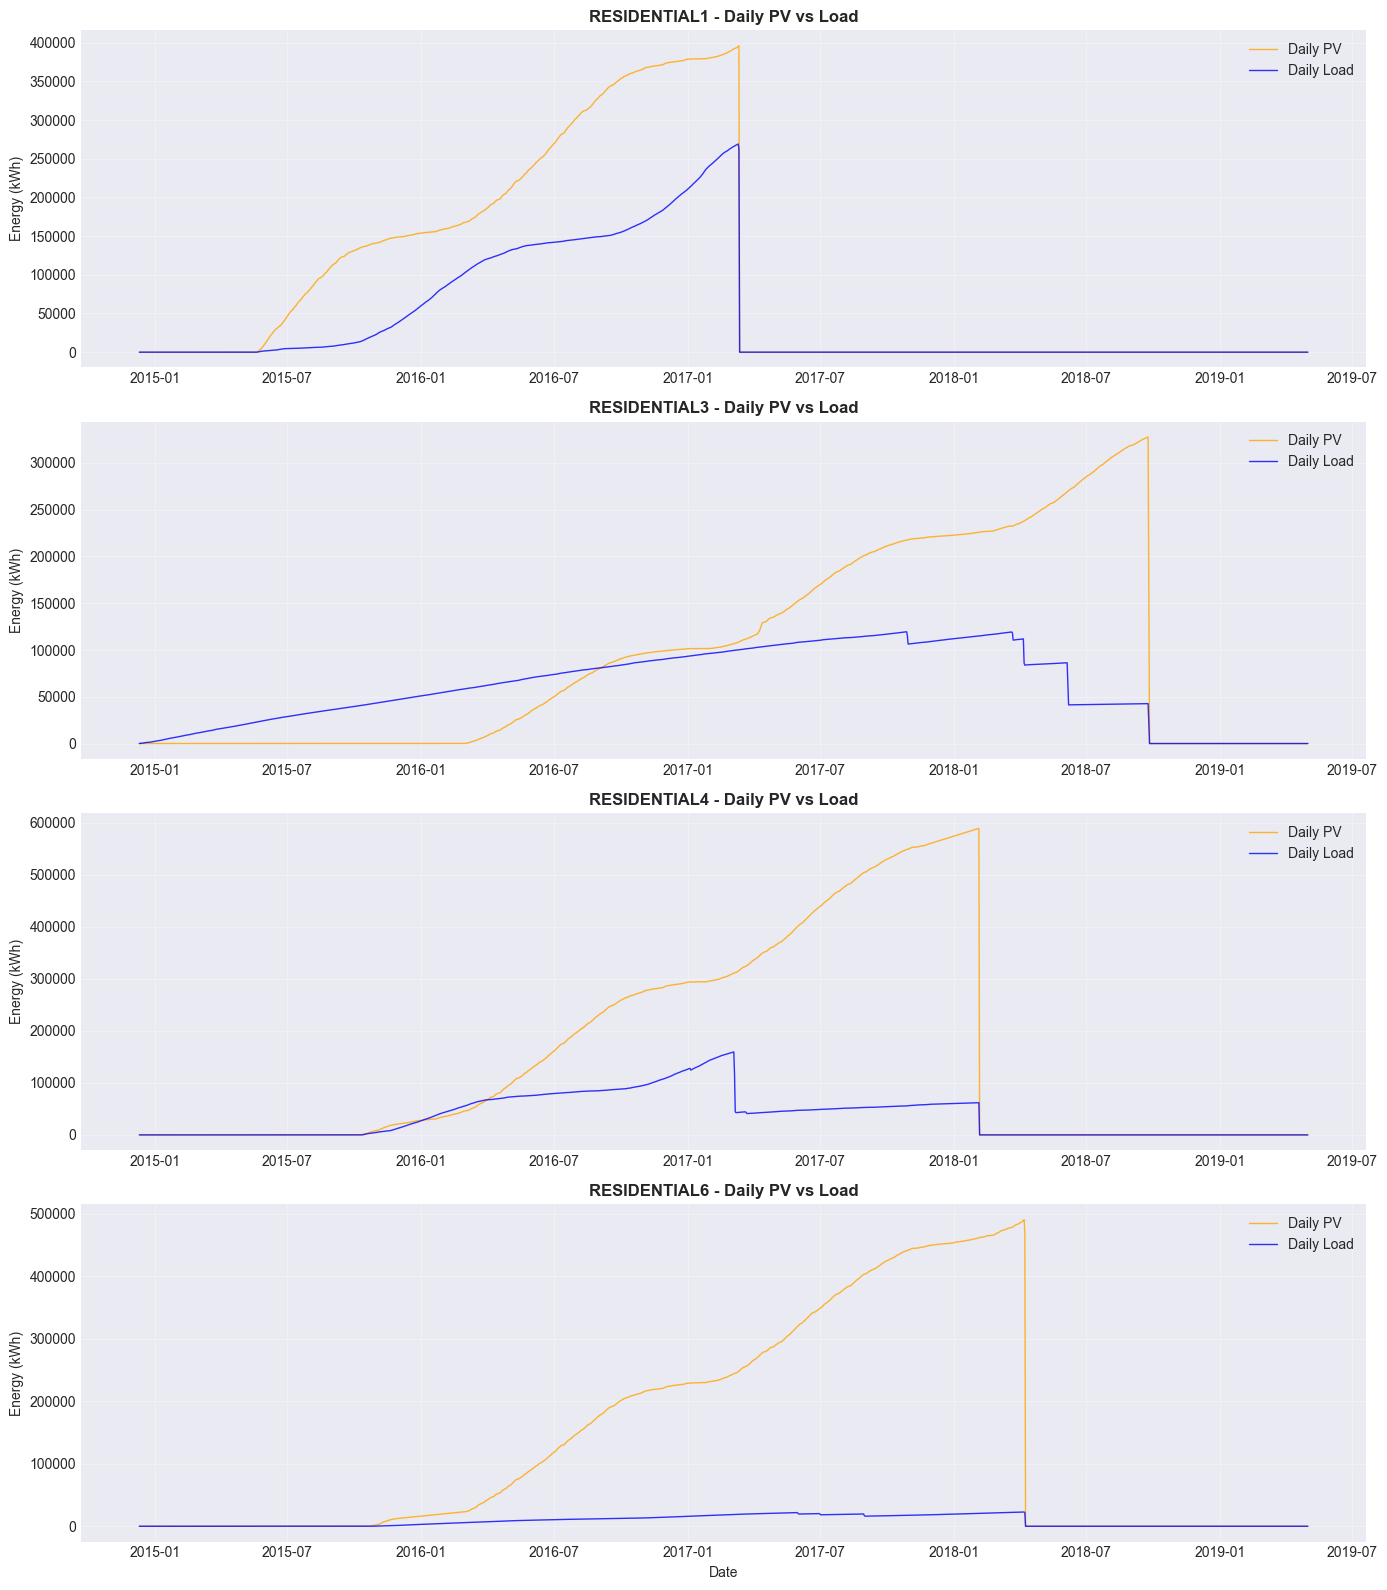

In [21]:
# Visualization: Daily PV and Load for all households
if not daily_energy.empty:
    fig, axes = plt.subplots(len(daily_energy['household'].unique()), 1, figsize=(14, 4*len(daily_energy['household'].unique())))
    
    if len(daily_energy['household'].unique()) == 1:
        axes = [axes]
    
    for idx, household in enumerate(sorted(daily_energy['household'].unique())):
        household_data = daily_energy[daily_energy['household'] == household]
        
        ax = axes[idx]
        ax.plot(pd.to_datetime(household_data['date'].astype(str)), household_data['daily_pv_kwh'], 
                label='Daily PV', linewidth=1, color='orange', alpha=0.8)
        ax.plot(pd.to_datetime(household_data['date'].astype(str)), household_data['daily_load_kwh'], 
                label='Daily Load', linewidth=1, color='blue', alpha=0.8)
        
        ax.set_title(f'{household.upper()} - Daily PV vs Load', fontweight='bold')
        ax.set_ylabel('Energy (kWh)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")

## 9. Next Steps

Based on this exploration:

1. **Data Preparation**: Create a comprehensive daily dataset aggregating all households
2. **Feature Engineering**: Add lag features, rolling averages, time-based features
3. **Model Development**: Train multiple regression models
4. **Evaluation**: Compare models using MAE, RMSE, R²
5. **Dashboard**: Build Streamlit dashboard for visualization

Key findings:
- Multiple households with solar PV and grid export capability
- Clear daily patterns in generation and export
- Opportunity to predict wastage based on historical patterns

In [ ]:
# Save sample daily data for next notebook
daily_data.to_csv('../data/processed/daily_sample_residential3.csv', index=False)
print("Sample daily data saved to: ../data/processed/daily_sample_residential3.csv")